In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as scp
import sys
import time

To run this notebook, you will need to pip install matplotlib, numpy, scipy, sys, time, and jupyter.

Download this file and move it to the directory where you want to work.

Navigate to that directory with your terminal and run "jupyter notebook"

This will open a browser window where you can open the notebook.

Find documentation on Jupyter <a href = "https://jupyter.org/install"> here</a>.

The goal of Bayesian parameter estimation is to obtain the a posterior distribution $P(\theta|d,h)$, which is a multidimensional probability distribution on the parameters of interest $\theta$ given the data $d$ and a chosen model $h$.

Bayes's theorem tells us that the posterior distribution is  

$$P(\theta|d,h) = \frac{\mathcal{L}(d|\theta,h)\pi(\theta)}{\mathcal{Z}(d,h)}\,.$$

- $\theta$ is a vector containing the model parameters.

- $h$ is our chosen model for describing the data.

- The evidence $\mathcal{Z}(d,h) = \displaystyle\int \mathcal{L}(d|{\theta},h)\pi({\theta})d{\theta}$ is the overall probability of observing $d$. For our purposes, it is a normalization factor, but it also plays an important role in model selection.

- The prior $\pi(\boldsymbol{\theta})$ is a probability distribution that contains our assumptions about the parameters before the observation is made.

- The likelihood $\mathcal{L}(d|\boldsymbol{\theta},h)$ is the probability of observing $d$ given the $\theta$ and $h$. We choose the likelihood based on our assumptions about the data generation process.

For binary parameter estimation, $\theta$ contains at least 15 parameters, and the relevant parameter space is quite large, making it infeasible to compute the posterior exactly or sample it on a grid. Instead, we use various stochastic sampling algorithms to approximate the posterior more efficiently.

Here, we will consider a simple toy problem to learn about two of the most common sampling algorithms: MCMC and Nested sampling.

# The data

Our data is a set of samples $\{x_i\}$ drawn from a normal distribution

$$ \mathcal{N}(x_i|\mu,\sigma) = \frac{1}{\sqrt{2\pi}\sigma}\exp\left[\frac{(x_i-\mu)^2}{2\sigma^2}\right]$$

with $\mu = 0$ and $\sigma=3$.

To generate our data, evaluate the cell below once and then comment it out. For now, we want to keep our dataset consistent.  

In [3]:
# np.savetxt("data-1.csv",scp.norm.rvs(loc =0, scale = 3, size =1000))

In [4]:
data = np.loadtxt("data-1.csv")

# The likelihood

The likelihood is the probability of observing the data given the model parameters

We will assume that we know the data was drawn from a normal distribution with $\mu=0$, but we don't know the value of $\sigma$. Our model paramters are ${\theta}  = \{\sigma\}$

The probability of observing a single data point $x_i$ is $\mathcal{N}(x_i|0,\sigma)$.

So the probability of observing the data set $d = \{x_i\}$ is

$$\mathcal{L}(d|{\theta}) = \prod_i\mathcal{N}(x_i|0,\sigma)$$

This will end up being a very small number, so we will work with the log of the likelihood instead.

$$\log\mathcal{L}(d|{\theta}) = \sum_i\log\mathcal{N}(x_i|0,\sigma)$$


There is no signal in our data to model with $h$, but the model is implicit in our choice to describe the distribution with a Gaussian.

In [5]:
def log_likelihood(data,sigma):

    shp  = np.shape(sigma)

    # if the likelihood is passed a scalar, return a scalar
    if shp == ():

        log_like = np.sum(np.log(scp.norm.pdf(data,loc = 0, scale = sigma)))

    # if it is passed an array, return an array
    else:

        log_like = np.array([])
        for el in sigma:
            log_like = np.append(log_like,np.sum(np.log(scp.norm.pdf(data,loc = 0, scale = el))))

    return log_like

# The prior

The prior contains our beliefs about the model parameters before the data was observed.

We will take the prior to be uniform on the range [1,5]

In [6]:
sigma_min = 1
sigma_max = 5

prior = scp.uniform(loc=sigma_min, scale=sigma_max-sigma_min)

def log_prior(sigma):
    return np.log(prior.pdf(sigma))

# The posterior

$$\log{P}({\theta}|d) =  \log\mathcal{L}(d|\sigma) +  \log\pi({\theta}) -  \log\mathcal{Z(d)}$$

For now, we will disregard the evidence because it is the same for every point in parameter space, and we can simply normalize the posterior samples afterward.

In [7]:
def log_posterior(sigma,data):

    shp  = np.shape(sigma)

    # if the likelihood is passed a scalar, return a scalar
    if shp == ():

        log_post = log_likelihood(data,sigma) + log_prior(sigma)

    # if it is passed an array, return an array
    else:

        log_post = np.array([])
        for el in sigma:
            log_post = np.append(log_post,log_likelihood(data,sigma) + log_prior(sigma))

    return log_post

# Markov Chain Monte Carlo (MCMC)

Here, I follow the text *Bayesian Logical Data Analysis for the Physical Sciences* by Phil Gregory

### Vocab breakdown:
**Markov Chain**: a stochastic process involving a series of events in which the probability of a given event depends only on the previous event

**Markov Chain Monte Carlo Algorithms**: Algorithms that use Markov chains to approximate a probability distribution

**Metropolis-Hastening Algorithm**: The specific MCMC algorithm we are going to use here

## Overview

An MCMC algorithm produces a "chain" of samples $\{\theta_0,\theta_1,...\theta_N\}$ that are distributed according to a probability distribution $p(\theta)$. The distribution we want to sample is the posterior ${P}({\theta}|d)$.

Given the $i^{th}$ sample $\theta_i$, we draw a prosal $\phi$ from a chosen proposal distribution $q(\phi|\theta_i)$. We compute the  Metropolis ratio

$r = \frac{p(\phi)}{p(\theta_i)}\frac{q(\theta_i|\phi)}{q(\phi|\theta_i)}\,,$

and draw a random sample $u$ from the uniform distribution on (0,1).

If $r\geq u$, we set $\theta_{i+1} = \phi$, otherwise set  $\theta_{i+1} = \theta_{i} $

### The Metropolises-Hastings Algorithm:  
Initialize the chain by selecting $\theta_0$

To determine $\theta_{i+1}$ given $\theta_i$:

1. Draw $\phi$ from the proposal distribution $q(\phi|\theta_i)$
2. Compute $r$ for $\theta_i$ and $\phi$
3. Draw $u$ from the uniform distribution (0,1)
4. If $r\geq u$, set $\theta_{i+1} = \phi$, else set  $\theta_{i+1} = x_{i} $

Repeat [1-4] until $i = N$

We will use a Gaussian proposal distribution i.e. we draw $\phi$ from a Gaussian centered at $\theta_i$
The scaling $\alpha$ determines how far $\phi$ is from $\theta_i$ and must be tuned to ensure adequate exploration of the parameter space.

$$ q(\phi|\theta_i)= \frac{1}{\sqrt{2\pi}\alpha}\exp\left[\frac{(\phi-\theta_i)^2}{2\alpha^2}\right]$$



In [8]:
# proposal distribution
def proposal(theta,alpha):
    return scp.norm.rvs(loc=theta, scale=alpha, size=1)[0]

# Metropolis ratio
# The second factor cancels because our proposal distribution is symmetric in theta_i and phi, but this is not always true.
def log_ratio(theta, phi):

    return log_posterior(phi,data) - log_posterior(theta,data)

def selector(theta,alpha):
    # draw a proposal
    phi = proposal(theta,alpha)
    # compute the Metropolis ratio
    r_log = log_ratio(theta, phi)
    # draw u
    u_log = np.log(scp.uniform.rvs(loc=0, scale=1, size=1)[0])
    # Either accept or reject phi and set theta_{t+1}
    if r_log>u_log:
        return phi
    else:
        return theta

def MCMC_sampler(N, alpha,theta0):
    # Set the initial time so we can time the sampler
    t_0 = time.time()
    # Initialize the chain:
    i = 0
    chain = [theta0] # the initial point can be anything, usually good to pick a reasonable guess
    # We are going to count the number of accepted proposals
    accept = 0
    while len(chain) < N:
        # set theta_{i+1} to be phi or theta_{t} based on the selector
        chain.append(selector(chain[-1],alpha))
        # set t = t+1
        i +=1
        # this counts acceptance rate,
        if chain[-1] != chain[-2]:
            accept += 1
        # every 10 samples, this will print the progress
        if (i/10).is_integer():
            sys.stdout.write(f"\r time = {time.time()-t_0:.2f}s [{100*i/N:.0f}%]")
            sys.stdout.flush()
    print(f"\n Acceptance rate: {100*accept/N} %")
    return chain

## Tuning the jump sizes

Try several different proposal scaling, $\alpha = 0.01$, $\alpha = 0.1$, $\alpha = 1.0$, $\alpha = 1.0$, $\alpha = 10.0$, and plot the chains. For now, keep $\theta_0$ at the edge of the prior, so we can more easily see what is going on.

 - Which one most effectively explores the distribution?
 - How does the acceptance rate relate to the effective exploration of the parameter space?

In [9]:
chain_1 = MCMC_sampler(1000,0.01,5);
chain_2 = MCMC_sampler(1000,0.1,5);
chain_3 = MCMC_sampler(1000,1,5);
chain_4 = MCMC_sampler(1000,10,5);

 time = 0.21s [20%]

/tmp/ipykernel_8635/681132756.py:7: RuntimeWarning: divide by zero encountered in log
  return np.log(prior.pdf(sigma))


 time = 1.02s [99%]
 Acceptance rate: 81.5 %
 time = 0.98s [99%]
 Acceptance rate: 59.0 %
 time = 0.55s [56%]

/tmp/ipykernel_8635/2763465271.py:8: RuntimeWarning: divide by zero encountered in log
  log_like = np.sum(np.log(scp.norm.pdf(data,loc = 0, scale = sigma)))


 time = 1.00s [99%]
 Acceptance rate: 9.0 %
 time = 0.90s [99%]
 Acceptance rate: 1.3 %


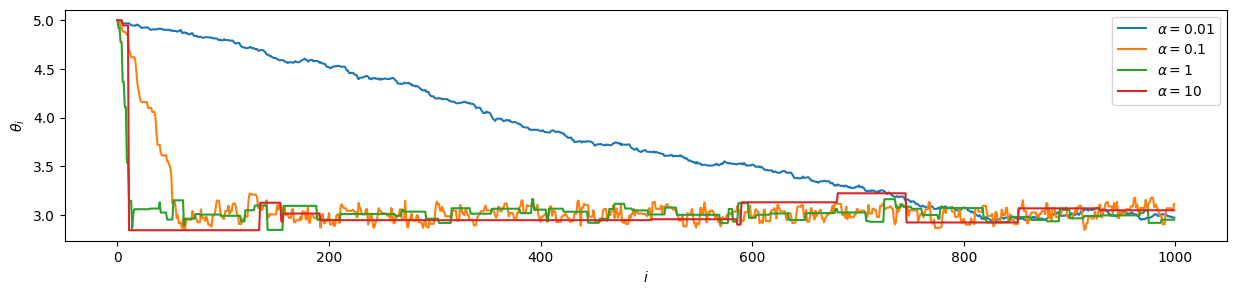

In [10]:
plt.figure(figsize=(15, 3))
plt.plot(chain_1,label ="$\\alpha =0.01$")
plt.plot(chain_2,label ="$\\alpha =0.1$")
plt.plot(chain_3,label ="$\\alpha =1$")
plt.plot(chain_4,label ="$\\alpha =10$")
plt.xlabel("$i$")
plt.ylabel("$\\theta_i$");
plt.legend()

## Remove the burn-in phase

If we select a $\theta_0$ in a low-probability region of the distribution, there will be a "burn-in" phase as the sampler moves towards the high-probability region.

- From the plot above, estimate the length for each scaling

## Thin the chain

It's important that our chain consists of independent samples. We will ensure this using autocorrelation.

The autocorrelation function is

$\rho(k) = \frac{\gamma(k)}{\gamma(0)}$

where

$\gamma(k) = \frac{1}{N-k}\sum_{i=1}^{N-k}(\theta_{i+k}-\bar \theta)(\theta_{i}-\bar \theta)$

and $\bar \theta$ is the mean value of the chain.

The autocorrelation length is the $k$ where $\rho(k)$ drops to $ \sim 0.01$

### What does this tell us?

The autocorrelation length tells us how many of our samples are independent. For a chain with autocorrelation length $k$, roughly one in every $k$ samples is independent, so we only have $N/k$ independent samples.

### How does this work?
If we subtract the mean $\bar \theta$ from our chain, our new distribution is centered around $0$.
If $\theta_{i+h}$ is truly independent from $\theta_{i}$,  then the product $(\theta_{i+k}-\bar \theta)(\theta_{i}-\bar \theta)$ is equally likely to be positive or negative,  and  the average $\gamma(k)$ will be zero.  

It is important that the length of the chain is much larger than the autocorrelation length, otherwise the value of the autocorrelation length might not be accurate.

We thin the chain by selecting every $k$  element and discarding the rest.

Important: The autocorrelation length should only be computed for the chain once the burn-in period has been removed.

In [11]:
def gamma(chain, h):
    m = np.mean(chain)
    N = len(chain)
    g = 0
    for i in range(N-h):
        g+= (chain[i+h]-m)*(chain[i]-m)
    g = g/(N-h)
    return g

def autocorrelation(chain, h):
    return gamma(chain, h)/gamma(chain, 0)

def get_thinned_chain(chain):
    h = 0 ;
    rho = 1;
    while rho >= .01:
        rho = autocorrelation(chain,h)
        h += 1
    chain_thinned = chain[::h]
    print(f"Autocorrelation Length: {h}")
    print(f"Thinned chain length: {len(chain_thinned)}")
    return chain_thinned

Because we know roughly where our distribution should be centered, let's rerun the samplers with $\theta_0=3$, to avoid having a burn-in period. We will also increase the length of the chain because that impacts autocorrelation length.  

In [12]:
chain_1 = MCMC_sampler(100000,0.01,3);
chain_2 = MCMC_sampler(100000,0.1,3);
chain_3 = MCMC_sampler(100000,1,3);
chain_4 = MCMC_sampler(100000,10,3);

 time = 107.55s [100%]
 Acceptance rate: 95.276 %
 time = 110.56s [100%]
 Acceptance rate: 59.511 %
 time = 0.22s [0%]

/tmp/ipykernel_8635/681132756.py:7: RuntimeWarning: divide by zero encountered in log
  return np.log(prior.pdf(sigma))


 time = 1.30s [1%]

/tmp/ipykernel_8635/2763465271.py:8: RuntimeWarning: divide by zero encountered in log
  log_like = np.sum(np.log(scp.norm.pdf(data,loc = 0, scale = sigma)))


 time = 108.89s [100%]
 Acceptance rate: 8.673 %
 time = 99.16s [100%]
 Acceptance rate: 0.86 %


Below, we plot $\rho(h)$ as a function of $h$. The autocorrelation length is the first $h$ where $\rho(h)$ drops below $0.01$

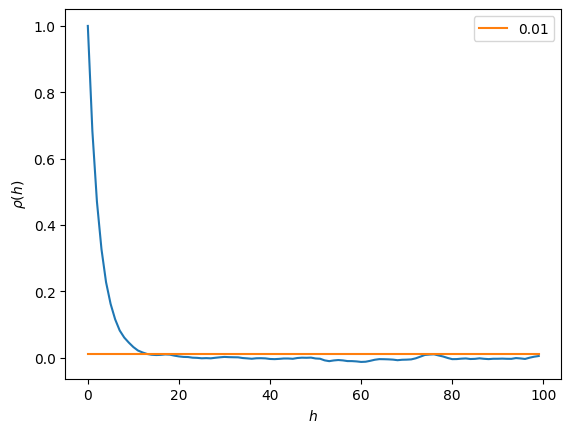

In [13]:
autocorr = []
for h in range(100):
    autocorr.append(autocorrelation(chain_2, h))

plt.plot(autocorr)
plt.plot(.01*np.ones_like(autocorr), label="0.01")
plt.xlabel("$h$")
plt.ylabel("$\\rho(h)$")
plt.legend();

Here, we compute the autocorrelation length for each chain and then thin the chain by selecting independant samples.

In [14]:
chain_1_thinned = get_thinned_chain(chain_1);
chain_2_thinned = get_thinned_chain(chain_2);
chain_3_thinned = get_thinned_chain(chain_3);
chain_4_thinned = get_thinned_chain(chain_4);

Autocorrelation Length: 1265
Thinned chain length: 80
Autocorrelation Length: 15
Thinned chain length: 6667
Autocorrelation Length: 43
Thinned chain length: 2326
Autocorrelation Length: 380
Thinned chain length: 264


## Generate the final posterior samples
Select the best proposal scaling and generate about $10^5-10^6$ samples. Either start the sampler in the high probability area or remove the burn-in  

In [17]:
scaling = 0.1

chain = MCMC_sampler(100000,scaling,3)

posterior_MCMC = get_thinned_chain(chain)

 time = 112.60s [100%]
 Acceptance rate: 59.659 %
Autocorrelation Length: 19
Thinned chain length: 5264


# Determine the credible interval

The whole point of Bayesian inference is to determine credible intervals on the parameters. This is how we propagate uncertainty in the data-collection process into uncertainty in our parameter measurements. Generally, we quote $90\%$ credible intervals, i.e., we believe that there is a $90\%$ chance that the true value of the parameter is within that interval. There is no unique way to determine the $90\%$ credible interval of a distribution because there are infinitely many intervals that contain $90\%$ of the probability. Determining the most useful credible interval becomes more complicated if the distribution is multimodal or asymmetric.  However, an easy, typical way to do it is to use the $5\%$ and $95\%$ quantiles as bounds.  See <a href = "https://en.wikipedia.org/wiki/Credible_interval"> this Wikipedia page </a>for other ways of defining credible intervals.


Note ~ In Bayesian statistics, one quotes credible intervals: For a $p\%$ credible interval, we believe there is a $p\%$ chance that the true value falls in that range. In frequentist statistics, one quotes confidence intervals. If the experiment is repeated many times and the $p\%$ confidence interval is determined each time, the confidence intervals will contain the true value $p\%$ of the time.

In [18]:
quantiles_MCMC = np.quantile(posterior_MCMC,[.05,.5,.95])

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8635/536833866.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(x=3, color='C3', label ="Injected $\sigma$")
/tmp/ipykernel_8635/536833866.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(x=np.sqrt(np.var(data)),color='C4',label ="Empirical $\sigma$")


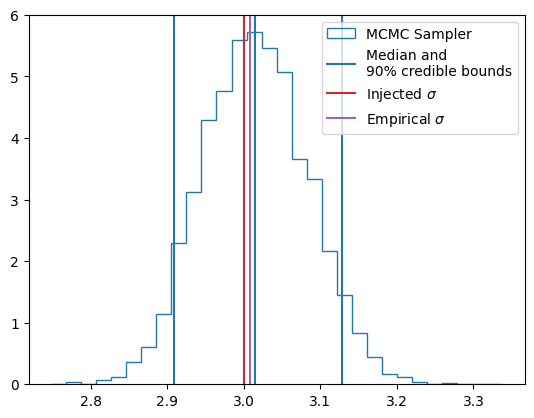

In [19]:

plt.hist(posterior_MCMC,30,density = True,histtype = 'step',label="MCMC Sampler");
plt.axvline(x=quantiles_MCMC[0],color='C0',label ="Median and\n90% credible bounds")
plt.axvline(x=quantiles_MCMC[1],color='C0')
plt.axvline(x=quantiles_MCMC[2],color='C0')
plt.axvline(x=3, color='C3', label ="Injected $\sigma$")
plt.axvline(x=np.sqrt(np.var(data)),color='C4',label ="Empirical $\sigma$")
plt.legend()

In the histogram above, we show both the true, or "injected," value $\sigma = 3$ and the empirical value, which is the algebraically computed variance of the data. This is the value that maximizes the likelihood. For more complicated data and models, the empirical value of a parameter is not something we can easily compute - that is what parameter estimation is for.


# Nested Sampling

Nested Sampling is an algorithm for computing the Bayesian evidence $\mathcal{Z}(d)$. We get the posterior samples "for free" as a byproduct. The algorithm was developed in 2004 by the physicist John Skilling (see <a href = "https://pubs.aip.org/aip/acp/article/735/1/395/748716/Nested-Sampling"> here </a> and <a href = "https://projecteuclid.org/journals/bayesian-analysis/volume-1/issue-4/Nested-sampling-for-general-Bayesian-computation/10.1214/06-BA127.full"> here </a>).  <a href = "https://arxiv.org/pdf/2205.15570"> This </a>  is the reference I follow here. The documentation for the nested sampling library  <a href = " https://dynesty.readthedocs.io/en/v3.0.0/index.html"> Dynesty </a>  also has good info.

The evidence is

$$\mathcal{Z}(d) = \displaystyle\int \mathcal{L}(d|{\theta})\pi({\theta})d{\theta}$$

We can compute integrals numerically by breaking up the integrand into small volume elements $\Delta{\theta}$ and adding them up:

$$\mathcal{Z}(d) =\lim_{\Delta{\theta}\rightarrow 0} \sum \mathcal{L}(d|{\theta})\pi({\theta}) \Delta{\theta}$$

Rather than using "cubes" $\Delta{\theta}$, nested sampling breaks up the likelihood into regions $\Delta X$ of almost constant likelihood (<a href = "https://arxiv.org/pdf/2205.15570">Figure 1a</a>). Think of the contour lines on a topographical map. The evidence is then


$$\mathcal{Z}(d) = \sum \mathcal{L}(X) \Delta X$$

where $\Delta X$ is the volume of space in which the likelihood equals $\mathcal{\mathcal{L}}(X)$, weighted by the prior $\pi({\theta})$.

The inverse gives the volume contained within the constraint $\mathcal{L}\geq L$

$$X(L) = \displaystyle\int_{\mathcal{L}\geq L}\pi({\theta}|h)d{\theta}$$


The values of the likelihood are bounded $0<\mathcal{L}(d|{\theta})<\mathcal{L}_\mathrm{max}$.
The value of $X$ will decrease monotonically from $X(0) = 1 $ ($100\%$ of the prior volume) to $X(\mathcal{L}_\mathrm{max}) = 0$ ($0\%$ of the prior volume).

Nested sampling works as follows:

Initialize by drawing $N$ "live points" from the prior: $\theta_1...\theta_{N}$

At iteration $i$.

 1. Compute the likelihood for each live point $[\mathcal{L}(\theta_1)...\mathcal{L}(\theta_N)]$.

 2. Set $L_i = \mathrm{min}[\mathcal{L}(\theta_1)...\mathcal{L}(\theta_N)]$.

 3. Save the corresponding $\theta$ (with $\mathcal{L}(\theta)= L_i$) as a "dead point," and remove it from the list of live points.

 4. Draw a new live point $\theta_\mathrm{new}$ from the prior with the contraint that $\mathcal{L}(\theta_\mathrm{new})>L_i$

Repeat [1-4] until a stopping criterion is reached.


With every iteration $i$, the volume of the prior $X(L_i)$ contracts. Nested sampling computes this volume statistically rather than geometrically, i.e., we employ an expectation value for the volume rather than computing an integral. This volume does not depend on either the form of the likelihood or the prior:

$X_i = X(L_i) = \exp(-i/N)$

See <a href = "https://arxiv.org/pdf/2205.15570"> this paper </a> for a derivation of this.

The evidence can then be computed:

$\mathcal{Z} =\sum_{i} L_{i}\frac{X_{i-1}-X_{i+1}}{2}$

$\mathcal{Z} =\sum_{i} L_{i}w_i$

Where $w_i = \frac{X_{i-1}-X_{i+1}}{2}$



But we wanted the posterior!

To get this, we reweight the dead points by

$$P_i = \frac{w_i L_i}{\mathcal{Z}}$$



At iteration $n$, the estimate of the evidence

$$\mathcal{Z_n} =\sum_{i}^{n} L_{i}w_i$$

gets closer to the true value $\mathcal{Z}_\mathrm{true}$.


To estimate the remaining evidence, we compute  $\Delta\log\mathcal{Z}_n = \log\mathcal{Z}_\mathrm{true} - \log\mathcal{Z_n}$ starts at $\infty$ at $n=0$ and approaches $0$ as $n$ grows.

The remaining evidence at iteration $n$ is approximately $\Delta \mathcal{Z}_\mathrm{true}- \mathcal{Z}_n = \mathcal{L}_\mathrm{max}X_n$, where $\mathcal{L}_\mathrm{max}$ is the maximum likelihood value among live points.

We set a lower bound on $\Delta\log\mathcal{Z}_n$ which ensures we recover a certain fraction of the evidence. This value may need to be tuned, but 0.01 is a good start.


In [22]:
def X(i,nlive):
    return np.exp(-i/nlive)

def w(i,nlive):
    return (X(i-1,nlive)-X(i+1,nlive))/2

In [23]:
def Nested_sampler(nlive,dlogz_min):

    # generate the live points
    live = prior.rvs(size=nlive);

    # initialize arrays to contain ...
    # ... the minimum likelihood values at each iteration
    log_Ls = np.array([])
    # ... the weights
    log_ws = np.array([])
    # the contribution to the evidence
    log_Zs = []
    # ... the dead points
    dead = np.array([])

    # set the counter
    i = 0
    # initial time
    t_0 = time.time()
    # initial dlogz
    dlogz =1

    while dlogz>dlogz_min:

        # update counter
        i += 1
        log_L_list = log_likelihood(data,live)
        # determine the minimum likelihood value, save it
        log_Ls = np.append(log_Ls,min(log_L_list))
        # and find its location
        index = np.where(log_L_list==log_Ls[-1])
        # add the corresponding live point to the list of dead points
        dead = np.append(dead,live[index])
        # and delete it from the live points
        live = np.delete(live,index)
        # compute the log weight, save it to an array
        log_ws = np.append(log_ws,np.log(w(i,nlive)))
        # compute the log of the contribution to the evidence at this point
        log_Zs = np.append(log_Zs,log_Ls[-1] + log_ws[-1])


        # stopping criteria
        log_dZ = np.log(X(i,nlive))+max(log_L_list)
        log_Z = np.logaddexp.reduce(log_Zs)
        dlogz = np.logaddexp(log_Z,log_dZ)-log_Z

        # search for a new live point with a likelihood value greater than L_i

        j  =0
        log_Lnew = np.log(0)
        while log_Lnew < log_Ls[-1]:
            j+=1
            # draw a new live point proposal from the prior
            xnew = prior.rvs(size=1)
            # compute the new likelihood value
            log_Lnew = log_likelihood(data,xnew)
        # add xnew to the live points when the likelihood value is greater than L
        live = np.append(live, xnew)


        #
        sys.stdout.write(f"\rtime: {time.time()-t_0:.2f}s iteration {i} samples to find live point: {j} dlogz={dlogz:.4f} > {dlogz_min}           ")
        sys.stdout.flush()

    # compute log Z
    log_Z = np.logaddexp.reduce(log_Zs)

    print(f"\nlog Z =  {log_Z} ")

    #compute the posterior weights
    post_weights = np.exp(log_Ls+log_ws - log_Z)

    # Finally, resample the deadpoints to obtain the posterior
    posterior = np.random.choice(dead, size=len(dead), p=post_weights)

    return posterior

In [24]:
posterior_Nested = Nested_sampler(1000,.01)

time: 0.30s iteration 1 samples to find live point: 1 dlogz=2932.4178 > 0.01           

/tmp/ipykernel_8635/20458687.py:50: RuntimeWarning: divide by zero encountered in log
  log_Lnew = np.log(0)


time: 2043.95s iteration 7797 samples to find live point: 1340 dlogz=0.0100 > 0.01           
log Z =  -2524.713813710011 


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8635/214273822.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(x=3, color='C3', label ="Injected $\sigma$")
/tmp/ipykernel_8635/214273822.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(x=np.sqrt(np.var(data)),color='C4',label ="Empirical $\sigma$")


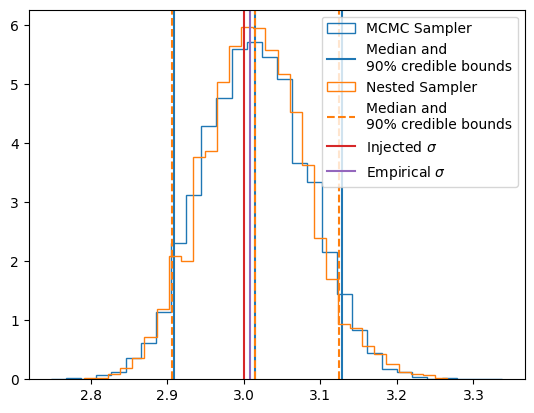

In [25]:
quantiles_Nested = np.quantile(posterior_Nested,[.05,.5,.95])
plt.hist(posterior_MCMC,30,density = True, color = "C0",histtype = 'step',label="MCMC Sampler");
plt.axvline(x=quantiles_MCMC[0],color='C0',label ="Median and\n90% credible bounds")
plt.axvline(x=quantiles_MCMC[1],color='C0')
plt.axvline(x=quantiles_MCMC[2],color='C0')
plt.hist(posterior_Nested,30,density = True, color = "C1",histtype = 'step',label="Nested Sampler");
plt.axvline(x=quantiles_Nested[0],color='C1',label ="Median and\n90% credible bounds",linestyle='--')
plt.axvline(x=quantiles_Nested[1],color='C1',linestyle='--')
plt.axvline(x=quantiles_Nested[2],color='C1',linestyle='--')
plt.axvline(x=3, color='C3', label ="Injected $\sigma$")
plt.axvline(x=np.sqrt(np.var(data)),color='C4',label ="Empirical $\sigma$")
plt.legend()

- Try running the sampler for different values of $n_\mathrm{live}$ and $\Delta\log\mathcal{Z}$ and see how it impacts the runtime and the resulting posterior distribution. Note that the number of samples required to find a new live point tends to increase with each iteration as the prior volume contracts.

The shape of the posterior distribution should only depend on the data, the chosen likelihood, and the prior, not the sampling parameters ($\alpha$ and $N$ for MCMC or $n_\mathrm{live}$ and $\Delta\log\mathcal{Z}$ for Nested). A good check for the sampler's convergence is to vary the sampling parameters and examine the resulting distribution. There is, of course, a balance between efficiency and accuracy - you want the fewest number of iterations to obtain a good approximation of the posterior.

Try generating new datasets and rerunning the MCMC and Nested samplers.

 - How does the number of data samples impact the bias between the median of the posterior and the injected value?
 - How does it impact the credible intervals

In this toy problem, the number of data samples is analogous to the SNR in binary parameter estimation.